In [ ]:
!pip install transformers -q
!pip install albumentations -U -q

import os
import cv2
import copy
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2
from transformers import Mask2FormerForUniversalSegmentation

warnings.filterwarnings("ignore")

In [ ]:
def get_image_mask_pairs(base_path, dataset_type):
    img_dir = os.path.join(base_path, 'Images', dataset_type)
    gt_dir = os.path.join(base_path, 'GT')

    pairs = []
    if os.path.exists(img_dir):
        for img_name in sorted(os.listdir(img_dir)):
            if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue

            img_path = os.path.join(img_dir, img_name)

            # Khớp tên file: camouflage_0001.jpg -> camouflage_0001.png
            pure_name = os.path.splitext(img_name)[0]
            mask_path = os.path.join(gt_dir, pure_name + ".png")

            if not os.path.exists(mask_path):
                # Thử lại với tên gốc nếu không tìm thấy đuôi .png
                mask_path = os.path.join(gt_dir, img_name)

            if os.path.exists(mask_path):
                pairs.append((img_path, mask_path))

    print(f">> [Dataset {dataset_type}]: Tìm thấy {len(pairs)} cặp ảnh-mask.")
    return pairs

class CamoDataset(Dataset):
    def __init__(self, root, image_set="Train", transform=None):
        self.image_mask_pairs = get_image_mask_pairs(root, image_set)
        self.transform = transform

    def __len__(self):
        return len(self.image_mask_pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.image_mask_pairs[idx]
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # Chuyển mask từ [0, 255] về nhãn [0, 1]
        mask = (mask > 128).astype(np.uint8)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img, mask = augmented['image'], augmented['mask']

        return img, mask.long()

In [ ]:
class AverageMeter(object):
    def __init__(self): self.reset()
    def reset(self): self.val = self.avg = self.sum = self.count = 0
    def update(self, val, n=1):
        self.val = val; self.sum += val * n; self.count += n; self.avg = self.sum / self.count

def intersectionAndUnionGPU(output, target, K):
    output = output.view(-1)
    target = target.view(-1)
    intersection = output[output == target]
    area_intersection = torch.histc(intersection.float(), bins=K, min=0, max=K-1)
    area_output = torch.histc(output.float(), bins=K, min=0, max=K-1)
    area_target = torch.histc(target.float(), bins=K, min=0, max=K-1)
    area_union = area_output + area_target - area_intersection
    return area_intersection, area_union, area_target

class EarlyStopping:
    def __init__(self, patience=10):
        self.patience = patience; self.counter = 0; self.best_loss = None; self.best_model = None
    def __call__(self, model, val_loss):
        if self.best_loss is None or val_loss < self.best_loss:
            self.best_loss = val_loss; self.best_model = copy.deepcopy(model.state_dict()); self.counter = 0
            return False
        self.counter += 1
        if self.counter >= self.patience:
            model.load_state_dict(self.best_model)
            return True
        return False

In [ ]:
def train_one_epoch(model, dataloader, device, optimizer, criterion, meter):
    model.train()
    pbar = tqdm(dataloader, desc="Training", colour="cyan")
    for img, mask in pbar:
        img, mask = img.to(device).float(), mask.to(device)
        optimizer.zero_grad()

        outputs = model(img)
        logits = F.interpolate(outputs.masks_queries_logits, size=mask.shape[-2:], mode="bilinear")

        loss = criterion(logits, mask)
        loss.backward()
        optimizer.step()

        meter.update(loss.item())
        pbar.set_postfix(loss=f"{loss.item():.4f}")

def evaluate(model, dataloader, device, K, i_m, u_m, t_m):
    model.eval()
    with torch.no_grad():
        for img, mask in dataloader:
            img, mask = img.to(device).float(), mask.to(device)
            outputs = model(img)
            logits = F.interpolate(outputs.masks_queries_logits, size=mask.shape[-2:], mode="bilinear")
            preds = logits.argmax(dim=1)

            i, u, t = intersectionAndUnionGPU(preds, mask, K)
            i_m.update(i); u_m.update(u); t_m.update(t)

    iou = i_m.sum / (u_m.sum + 1e-10)
    acc = i_m.sum / (t_m.sum + 1e-10)
    dice = (2 * i_m.sum) / (u_m.sum + i_m.sum + 1e-10)

    return iou.mean().item(), acc.mean().item(), dice.mean().item()

In [ ]:
# Cấu hình
DATA_PATH = "/kaggle/input/datasets/quanganhnguynquc/camodataset/CAMO-V.1.0-CVIU2019"
NUM_CLASSES = 2
BATCH_SIZE = 4 # Giảm xuống 2 nếu bị hết RAM GPU
EPOCHS = 50
LR = 1e-4

# Augmentation
train_trans = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])
val_trans = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Dataloader
train_ds = CamoDataset(DATA_PATH, "Train", train_trans)
val_ds = CamoDataset(DATA_PATH, "Test", val_trans)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Mask2FormerForUniversalSegmentation.from_pretrained(
    "facebook/mask2former-swin-small-ade-semantic",
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
criterion = torch.nn.CrossEntropyLoss()
es = EarlyStopping(patience=10)

# Training Loop
best_iou = 0
for epoch in range(EPOCHS):
    loss_meter = AverageMeter()
    train_one_epoch(model, train_loader, device, optimizer, criterion, loss_meter)

    i_m, u_m, t_m = AverageMeter(), AverageMeter(), AverageMeter()
    miou, macc, mdice = evaluate(model, val_loader, device, NUM_CLASSES, i_m, u_m, t_m)

    print(f"Epoch {epoch+1:02d} | Loss: {loss_meter.avg:.4f} | Acc: {macc:.4f} | mIoU: {miou:.4f} | Dice: {mdice:.4f}")

    if miou > best_iou:
        best_iou = miou
        torch.save(model.state_dict(), "model_best.pth")
        print(">>> Đã lưu model tốt nhất!")

    if es(model, 1-miou):
        print("Dừng sớm do mIoU không cải thiện.")
        break

>> [Dataset Train]: Tìm thấy 1000 cặp ảnh-mask.
>> [Dataset Test]: Tìm thấy 250 cặp ảnh-mask.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/276M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/782 [00:00<?, ?it/s]

Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-small-ade-semantic
Key                    | Status   |                                                                                       
-----------------------+----------+---------------------------------------------------------------------------------------
class_predictor.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([151, 256]) vs model:torch.Size([3, 256])
class_predictor.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([151]) vs model:torch.Size([3])          
criterion.empty_weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([151]) vs model:torch.Size([3])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
Training: 100%|██████████| 250/250 [01:09<00:00,  3.58it/s, loss=0.1639]


...

Epoch 20 | Loss: 0.0579 | Acc: 0.8572 | mIoU: 0.7796 | Dice: 0.8697


Training: 100%|██████████| 250/250 [01:11<00:00,  3.51it/s, loss=0.0281]


Epoch 21 | Loss: 0.0497 | Acc: 0.8476 | mIoU: 0.7735 | Dice: 0.8653


Training: 100%|██████████| 250/250 [01:10<00:00,  3.52it/s, loss=0.0453]


Epoch 22 | Loss: 0.0476 | Acc: 0.7788 | mIoU: 0.7177 | Dice: 0.8224
Dừng sớm do mIoU không cải thiện.


Loading weights:   0%|          | 0/782 [00:00<?, ?it/s]

Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-small-ade-semantic
Key                    | Status   |                                                                                       
-----------------------+----------+---------------------------------------------------------------------------------------
class_predictor.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([151, 256]) vs model:torch.Size([3, 256])
class_predictor.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([151]) vs model:torch.Size([3])          
criterion.empty_weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([151]) vs model:torch.Size([3])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


>> [Dataset Test]: Tìm thấy 250 cặp ảnh-mask.


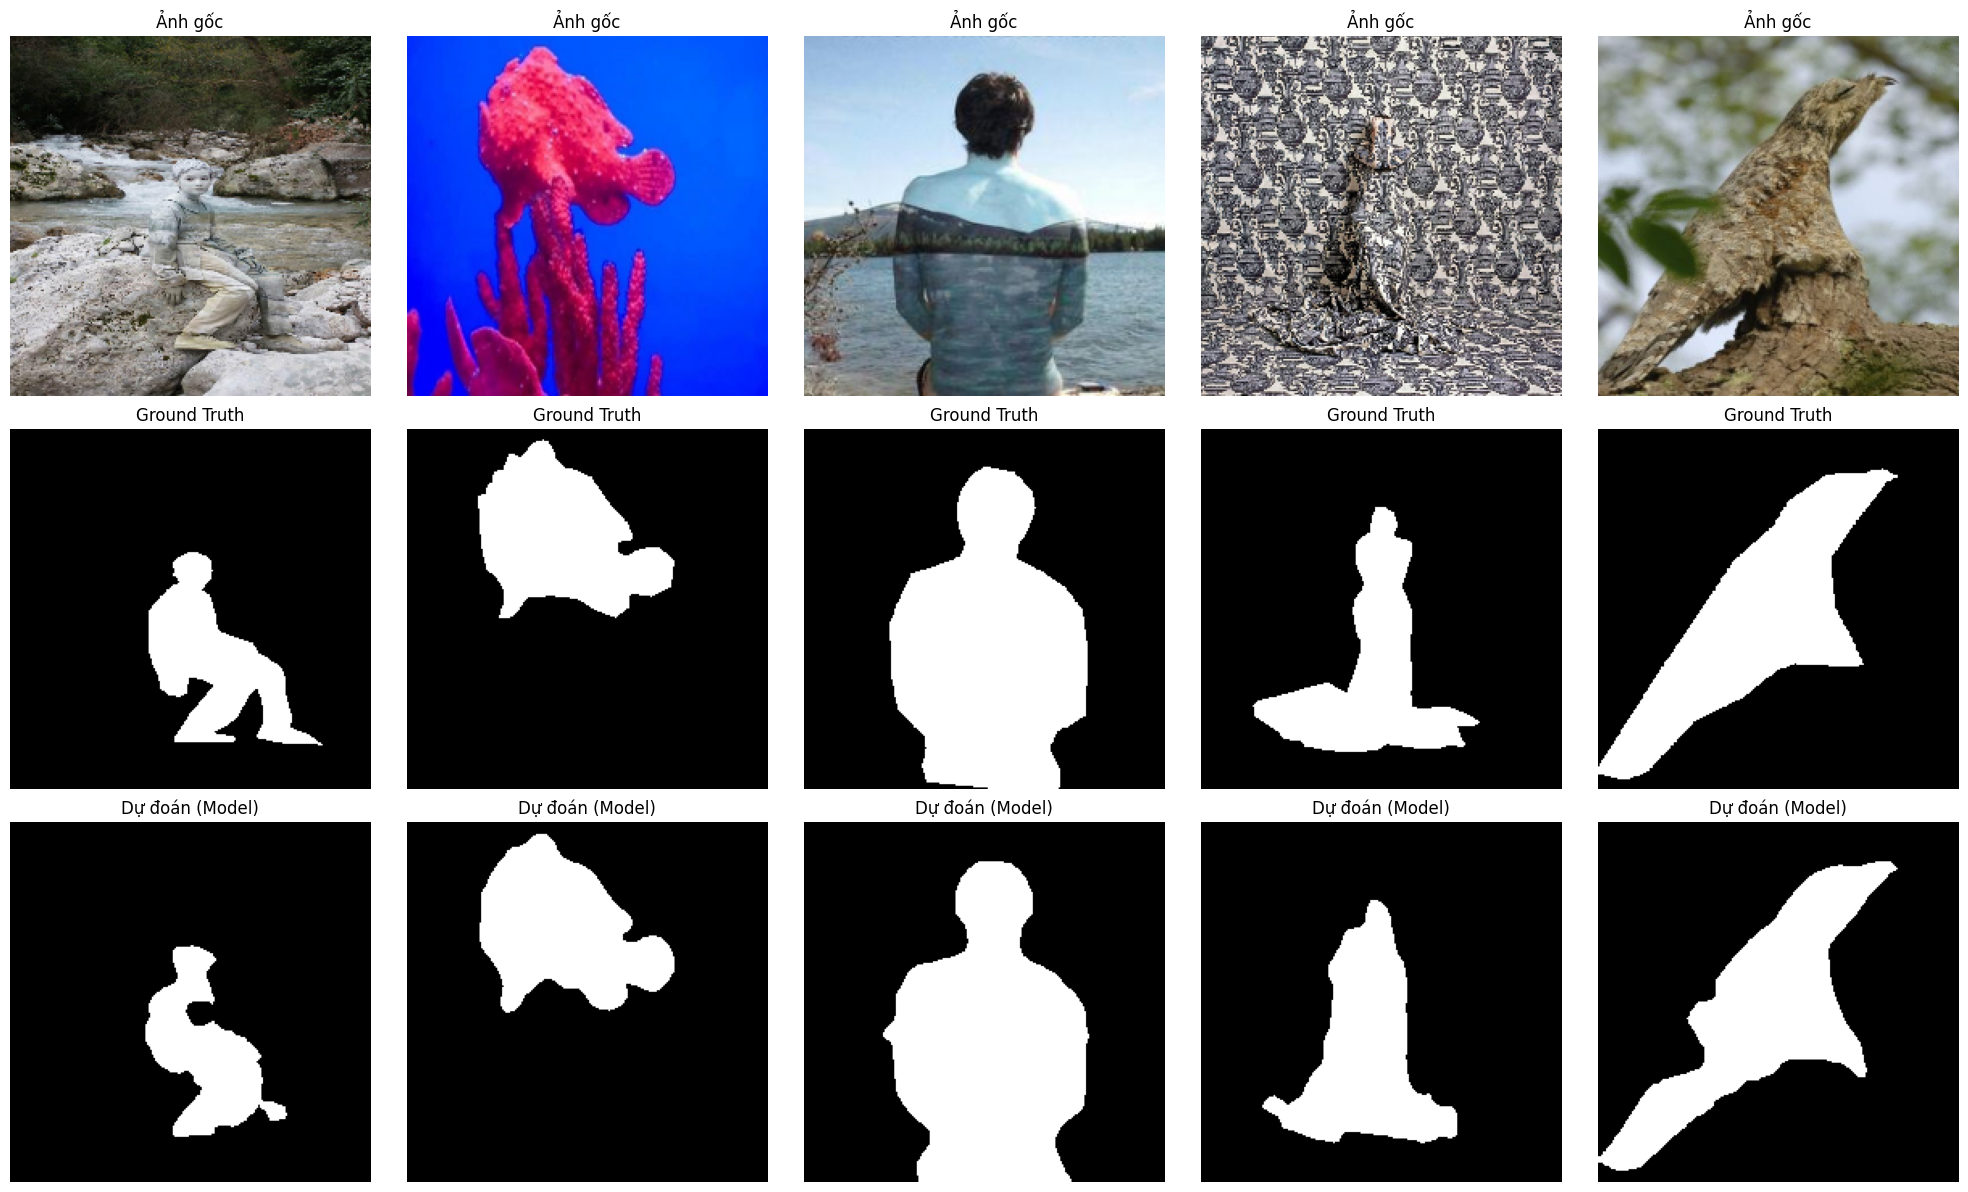

In [ ]:
class UnNormalize(object):
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std
    def __call__(self, tensor):
        for t, m, s in zip(tensor, self.mean, self.std):
            t.mul_(s).add_(m)
        return tensor

def pred_show_image_grid(model_pth, device, test_transform, num_classes, num_imgs):
    # Khởi tạo model và tải trọng số tốt nhất
    model = Mask2FormerForUniversalSegmentation.from_pretrained(
        "facebook/mask2former-swin-small-ade-semantic",
        num_labels=num_classes, ignore_mismatched_sizes=True
    )
    model.load_state_dict(torch.load(model_pth))
    model.to(device)
    model.eval()

    # Tải dữ liệu test
    image_dataset = CamoDataset(DATA_PATH, image_set="Test", transform=test_transform)
    unorm = UnNormalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))

    # Lấy ngẫu nhiên ảnh
    if isinstance(num_imgs, int):
        selected_ids = np.random.choice(len(image_dataset), num_imgs, replace=False)
    else:
        selected_ids = num_imgs

    images, orig_masks, pred_masks = [], [], []

    with torch.no_grad():
        for idx in selected_ids:
            img, mask = image_dataset[idx]

            # Dự đoán
            img_input = img.unsqueeze(0).to(device).float()
            outputs = model(img_input)
            logits = F.interpolate(outputs.masks_queries_logits, size=mask.shape, mode="bilinear")
            pred = logits.argmax(dim=1).squeeze().cpu().numpy()

            # Lưu lại để hiển thị
            images.append(unorm(img.clone()).permute(1, 2, 0).cpu().numpy())
            orig_masks.append(mask.cpu().numpy())
            pred_masks.append(pred)

    # Vẽ biểu đồ
    num_selected = len(selected_ids)
    fig, axes = plt.subplots(3, num_selected, figsize=(4 * num_selected, 12))
    titles = ["Ảnh gốc", "Ground Truth", "Dự đoán (Model)"]

    for i in range(num_selected):
        # Đảm bảo ảnh không bị lỗi màu khi plot
        img_show = np.clip(images[i], 0, 1)

        # Nếu num_selected == 1, axes là mảng 1 chiều, ngược lại là 2 chiều
        ax_img = axes[0, i] if num_selected > 1 else axes[0]
        ax_gt = axes[1, i] if num_selected > 1 else axes[1]
        ax_pred = axes[2, i] if num_selected > 1 else axes[2]

        ax_img.imshow(img_show); ax_img.set_title(titles[0]); ax_img.axis("off")
        ax_gt.imshow(orig_masks[i], cmap='gray'); ax_gt.set_title(titles[1]); ax_gt.axis("off")
        ax_pred.imshow(pred_masks[i], cmap='gray'); ax_pred.set_title(titles[2]); ax_pred.axis("off")

    plt.tight_layout()
    plt.show()

# Gọi hàm Inference để xem 5 ảnh ngẫu nhiên
pred_show_image_grid(
    model_pth="model_best.pth",
    device=device,
    test_transform=val_trans,
    num_classes=NUM_CLASSES,
    num_imgs=5 # Thay bằng một list index nếu muốn xem ảnh cụ thể, ví dụ: [1, 5, 10]
)